# Notebook 4: Modular cost-to-go for mixed-integer MPC
### Proof of concept for WP2.3: inventory control with lot-sized orders
- Dinesh Krishnamoorthy (dinesh.krishnamoorthy@ntnu.no)

**Setup.** A single inventory with a known, constant demand $d$:

$$x_{k+1} \;=\; x_k + u_k - d, \qquad u_k \in \{0,\ 5\}.$$

$x$ is the inventory level (positive = stock on hand, negative = backlog) and is **unconstrained**; $u$ is the order, which comes in **lots of 5 units**: either a full lot is bought, or nothing. We want to drive $x$ to a safety stock $x_{\rm ref}$.

**Why integrality matters.** With a continuous order $u\in[0,5]$, the controller can order exactly the demand and hold the inventory at $x_{\rm ref}$. With lots, it cannot: it has to buy a lot every $5/d$ steps or so, and the inventory swings by 5 units. The cost-to-go of the mixed-integer MPC therefore differs from that of its continuous relaxation.

**The expert.** A long-horizon mixed-integer MPC, solved exactly.

**The idea.** Integrality is treated as one more input of the cost-to-go, anchored at its relaxed value. This gives the baseline-plus-correction pattern

$$V_{\rm int}(x,d) \;=\; \underbrace{V_{\rm rel}(x,d)}_{\text{relaxed baseline }} \;+\; \underbrace{\Delta(x,d)}_{\text{integrality module}}.$$

The baseline comes from a cheap convex solver. Only the integrality module $\Delta$ needs the mixed-integer expert, and it is decomposed further by anchored ANOVA at $(\bar x, d_0) = (x_{\rm ref}, 1.5)$:

$$\Delta(x,d) \;=\; \underbrace{\Delta_0(x)}_{\text{integrality at nominal demand}}
+ \underbrace{\Delta_d(d)}_{\text{demand alone}}
+ \underbrace{\Delta_{xd}(x,d)}_{\text{interaction}}.$$

NB! $\Delta_d(d)$ does not depend on $x$, so it cannot affect the decision of a one-step MPC.

This notebook does the following:
1. Builds two experts on the same objective: the relaxed MPC (continuous order) and the mixed-integer MPC (lots).
2. Applies the anchored ANOVA decomposition to the integrality module, and checks which parts can change the decision.
3. Learns the relaxed baseline and the first-order integrality modules $\hat\Delta_0, \hat\Delta_d$ with RBF networks, from cheap relaxed solves and 1-D sweeps of the mixed-integer expert.
4. Learns the interaction $\hat\Delta_{xd}$, and compares the **modular reconstruction** $\hat V_{\rm rel}+\hat\Delta_0+\hat\Delta_d+\hat\Delta_{xd}$ with a monolithic RBF fit on the same mixed-integer data.
5. Compares the 1-step integer MPC with each learned cost-to-go against the expert, in its first order and in closed loop.

In [23]:
import time
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are
from scipy.interpolate import RBFInterpolator

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})

## 0. Problem data

The stage cost penalizes deviations from the steady state of the relaxed problem, $(x_{\rm ref},\,u_s=d)$,

$$\ell(x,u,d) \;=\; q\,(x - x_{\rm ref})^2 + r\,(u - d)^2,$$

with no discounting. Both experts use the same horizon and the same terminal cost $P\,(x_N-x_{\rm ref})^2$, with $P$ from the scalar Riccati equation of the relaxed problem. The only difference between them is the set of admissible orders: $u\in[0,5]$ for the relaxed expert, and $u\in\{0,5\}$ for the mixed-integer expert. The relaxed feasible set contains the integer one, so $V_{\rm rel}\le V_{\rm int}$ by construction.

In [24]:
q, r    = 1.0, 0.5          # inventory deviation cost, order cost
x_ref   = 5.0               # target inventory (safety stock)
LOT     = 5.0               # lot size: u in {0, LOT} (mixed-integer),  u in [0, LOT] (relaxed)
N_EXP   = 40                # expert horizon
U_SET   = np.array([0.0, LOT])

XLO, XHI = -4.0, 16.0       # inventory range on which V is built and learned
DLO, DHI = 0.5, 2.5         # demand range (known, constant over the horizon)
x_bar, d_0 = x_ref, 1.5     # ANOVA anchor: target inventory, nominal demand

P = float(np.squeeze(solve_discrete_are(np.array([[1.0]]), np.array([[1.0]]),
                                        np.array([[q]]), np.array([[r]]))))


## 1. Two experts on one objective

**Relaxed expert.** A convex QP over the horizon, with $0\le u_k\le 5$:

$$V_{\rm rel}(x,d)=\min_{u_{0:N-1}\in[0,5]}\ \sum_{k=0}^{N-1}\ell(x_k,u_k,d) + P\,(x_N-x_{\rm ref})^2,\qquad x_0=x,\quad x_{k+1}=x_k+u_k-d.$$

**Mixed-integer expert.** The same problem with $u_k\in\{0,5\}$. A generic MIQP solver would face $2^{40}$ order sequences. Here the problem can be solved *exactly* by dynamic programming.

NB! This exact solve is a property of this simple scalar example. In general the mixed-integer expert is a branch-and-bound MIQP/MINLPs, and each query is expensive. So the computing times below are not representative.

In [25]:
def build_relaxed(N=N_EXP):
    x0 = cp.Parameter(); d = cp.Parameter()
    X = cp.Variable(N + 1); U = cp.Variable(N)
    cost = q * cp.sum_squares(X[:N] - x_ref) + r * cp.sum_squares(U - d) + P * cp.square(X[N] - x_ref)
    con = [X[0] == x0, X[1:] == X[:N] + U - d, U >= 0, U <= LOT]          # <-- relaxed: 0 <= u <= LOT
    prob = cp.Problem(cp.Minimize(cost), con)

    def V(x, dd, want_u=False):
        x0.value = float(x); d.value = float(dd)
        try:
            prob.solve(solver=cp.CLARABEL)
        except Exception:
            return (np.nan, None) if want_u else np.nan
        if prob.status not in ("optimal", "optimal_inaccurate"):
            return (np.nan, None) if want_u else np.nan
        return (prob.value, float(U[0].value)) if want_u else prob.value
    return V


M_LAT = np.arange(N_EXP + 1)                     # m = number of lots bought so far


def V_integer(xs, d, want_u=False):
    # exact mixed-integer expert (u in {0, LOT}): dynamic programming on the lattice x_k = x0 + LOT*m - k*d
    # vectorised over an array of initial inventories xs, for a scalar demand d
    xs = np.atleast_1d(np.asarray(xs, float))
    W = P * (xs[:, None] + LOT * M_LAT - N_EXP * d - x_ref) ** 2                # terminal cost, (len(xs), N+1)
    for k in range(N_EXP - 1, -1, -1):
        Wn = np.concatenate([W, np.full((xs.size, 1), np.inf)], axis=1)        # m + 1 > N is unreachable
        wait = r * d ** 2 + Wn[:, M_LAT]                                        # u = 0
        buy = r * (LOT - d) ** 2 + Wn[:, M_LAT + 1]                            # u = LOT
        if k == 0:
            u0 = np.where(buy[:, 0] < wait[:, 0], LOT, 0.0)
        W = q * (xs[:, None] + LOT * M_LAT - k * d - x_ref) ** 2 + np.minimum(wait, buy)
    return (W[:, 0], u0) if want_u else W[:, 0]


V_relaxed = build_relaxed()
V_relaxed(0.0, 1.5)                               # warm up the compiled problem
t0 = time.time(); vr, ur = V_relaxed(0.0, 1.5, want_u=True); t_r = time.time() - t0
t0 = time.time(); vi, ui = V_integer(0.0, 1.5, want_u=True); t_i = time.time() - t0
  

### Both cost-to-go functions on a grid

We evaluate both experts on a grid over $[x_{lo},x_{hi}]\times[d_{lo},d_{hi}]$. This is the ground truth for the rest of the notebook (no fitting).

In [26]:
NX, ND = 81, 41
xg = np.linspace(XLO, XHI, NX)
dg = np.linspace(DLO, DHI, ND)
GX, GD = np.meshgrid(xg, dg, indexing="ij")          # GX[i, j] = xg[i],  GD[i, j] = dg[j]

t0 = time.time()
VINT = np.empty((NX, ND)); UINT = np.empty((NX, ND))
for j, dv in enumerate(dg):
    VINT[:, j], UINT[:, j] = V_integer(xg, dv, want_u=True)       # one DP per demand, vectorised over x
t_int = time.time() - t0
t0 = time.time()
VREL = np.empty((NX, ND)); UREL = np.empty((NX, ND))
for i, xv in enumerate(xg):
    for j, dv in enumerate(dg):
        VREL[i, j], UREL[i, j] = V_relaxed(xv, dv, want_u=True)
t_rel = time.time() - t0
print(f"mixed-integer expert: {NX*ND} solves in {t_int:4.1f} s     relaxed expert: {NX*ND} solves in {t_rel:4.1f} s")

DELTA = VINT - VREL
print(f"\nlower bound V_rel <= V_int:  min (V_int - V_rel) = {DELTA.min():.2f},  violations: {(DELTA < -1e-6).sum()}")
print(f"V_int ranges over {VINT.min():.0f} .. {VINT.max():.0f};  the integrality gap Delta = V_int - V_rel "
      f"ranges over {DELTA.min():.0f} .. {DELTA.max():.0f}")

I_BAR = int(np.argmin(abs(xg - x_bar))); J_0 = int(np.argmin(abs(dg - d_0)))
x_bar, d_0 = xg[I_BAR], dg[J_0]                       # anchor on the grid

mixed-integer expert: 3321 solves in  0.0 s     relaxed expert: 3321 solves in  2.2 s

lower bound V_rel <= V_int:  min (V_int - V_rel) = 61.61,  violations: 0
V_int ranges over 123 .. 1016;  the integrality gap Delta = V_int - V_rel ranges over 62 .. 250


A 1-step integer MPC chooses between buying a lot and waiting:

$$u^\star(x,d)=\arg\min_{u\in\{0,5\}}\ \ell(x,u,d) + V\big(x+u-d,\ d\big).$$

With $V=V_{\rm int}$, it should reproduce the expert. Two shortcuts ignore integrality in the future: using the relaxed cost-to-go $V=V_{\rm rel}$, or rounding the relaxed expert's first order to the nearer of $\{0,5\}$. 

## 2. The anchored-ANOVA decomposition of the integrality module

With anchor $(\bar x, d_0)$, the modules of $\Delta = V_{\rm int} - V_{\rm rel}$ are read directly off the two experts:

$$\Delta_0(x)=\Delta(x,d_0),\qquad \Delta_d(d)=\Delta(\bar x,d)-\Delta(\bar x,d_0),\qquad \Delta_{xd}(x,d)=\Delta(x,d)-\Delta_0(x)-\Delta_d(d).$$

$\Delta_d$ and $\Delta_{xd}$ vanish on the anchor cross, so $V_{\rm int} = V_{\rm rel} + \Delta_0 + \Delta_d + \Delta_{xd}$ is exact by construction.

**Which parts can change the decision?** The 1-step MPC compares two successors exactly one lot apart,

$$J(5)-J(0) \;=\; \big[\ell(x,5,d)-\ell(x,0,d)\big] \;+\; \Big[V\big(x+5-d,\,d\big)-V\big(x-d,\,d\big)\Big],$$

so only the **lot difference** $V(x+5,d)-V(x,d)$ of the cost-to-go matters. $\Delta_d$ cancels in it, and so does any part of $\Delta$ that repeats when $x$ shifts by one lot.

In [27]:
D0 = DELTA[:, J_0].copy()                          # Delta(x, d_0)
Dd = DELTA[I_BAR, :] - DELTA[I_BAR, J_0]           # Delta(x_bar, d) - Delta(x_bar, d_0)
Dxd = DELTA - D0[:, None] - Dd[None, :]            # interaction

print(f"exactness     |V_rel + D0 + Dd + Dxd - V_int|    max {np.abs(VREL + D0[:, None] + Dd[None, :] + Dxd - VINT).max():.1e}")
print(f"anchor cross  |Dxd(., d_0)|, |Dxd(x_bar, .)|      max "
      f"{max(np.abs(Dxd[:, J_0]).max(), np.abs(Dxd[I_BAR, :]).max()):.1e}")

rms = lambda Z: float(np.sqrt(np.mean(np.asarray(Z) ** 2)))
SHIFT = int(round(LOT / (xg[1] - xg[0])))          # grid steps per lot (the grid spacing divides the lot size)
lot = lambda Z: Z[SHIFT:] - Z[:-SHIFT]             # lot difference  Z(x + LOT, d) - Z(x, d)  on the grid

full_g = lambda Z1: np.broadcast_to(Z1, GX.shape)
print(f"\n{'':22s} {'rms about mean':>15s} {'rms of lot difference':>22s}")
for name, Z in [("V_int", VINT), ("V_rel (baseline)", VREL), ("Delta = V_int - V_rel", DELTA),
                ("  Delta_0", full_g(D0[:, None])), ("  Delta_d", full_g(Dd[None, :])), ("  Delta_xd", Dxd)]:
    print(f"{name:22s} {rms(Z - Z.mean()):15.2f} {rms(lot(Z)):22.2f}")

exactness     |V_rel + D0 + Dd + Dxd - V_int|    max 1.1e-13
anchor cross  |Dxd(., d_0)|, |Dxd(x_bar, .)|      max 0.0e+00

                        rms about mean  rms of lot difference
V_int                           104.07                 132.91
V_rel (baseline)                117.12                 143.86
Delta = V_int - V_rel            30.21                  13.56
  Delta_0                        10.56                  11.64
  Delta_d                        26.55                   0.00
  Delta_xd                       10.25                   4.89


The integrality gap is large in value: $\Delta$ ranges from 62 to 250. Most of it is the demand-only module $\Delta_d$, which captures how the cost of cycling with lots grows with the demand. It does not depend on $x$, so it cancels in the decision.

The part of the gap that the decision sees is much smaller: the lot difference of $\Delta$ has an rms of 14, against 133 for $V_{\rm int}$. The relaxed baseline therefore carries most of the decision-relevant signal, and the integrality module corrects about a tenth of it. Of that correction, $\Delta_0$ carries the largest share. The interaction $\Delta_{xd}$ is as large as $\Delta_0$ in value, but half of it cancels in the lot difference.

## 3. Visualize the decomposition

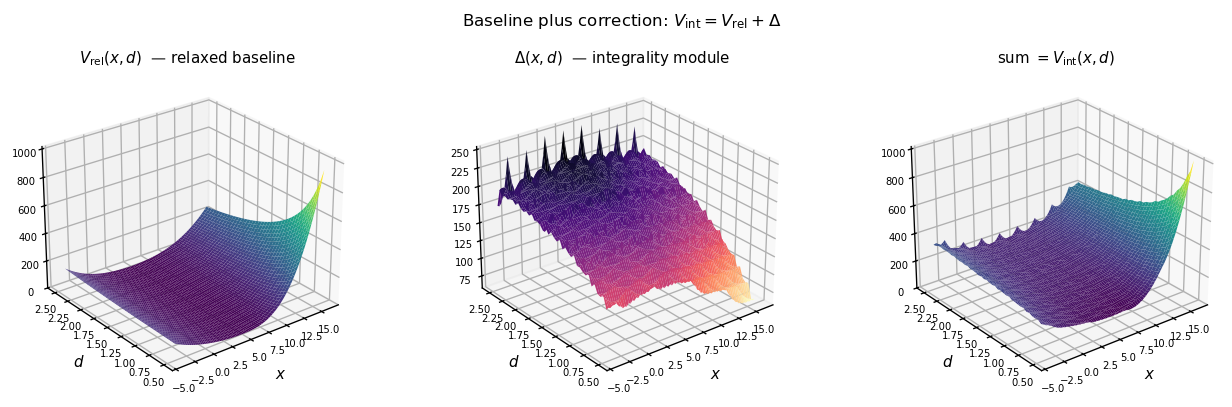

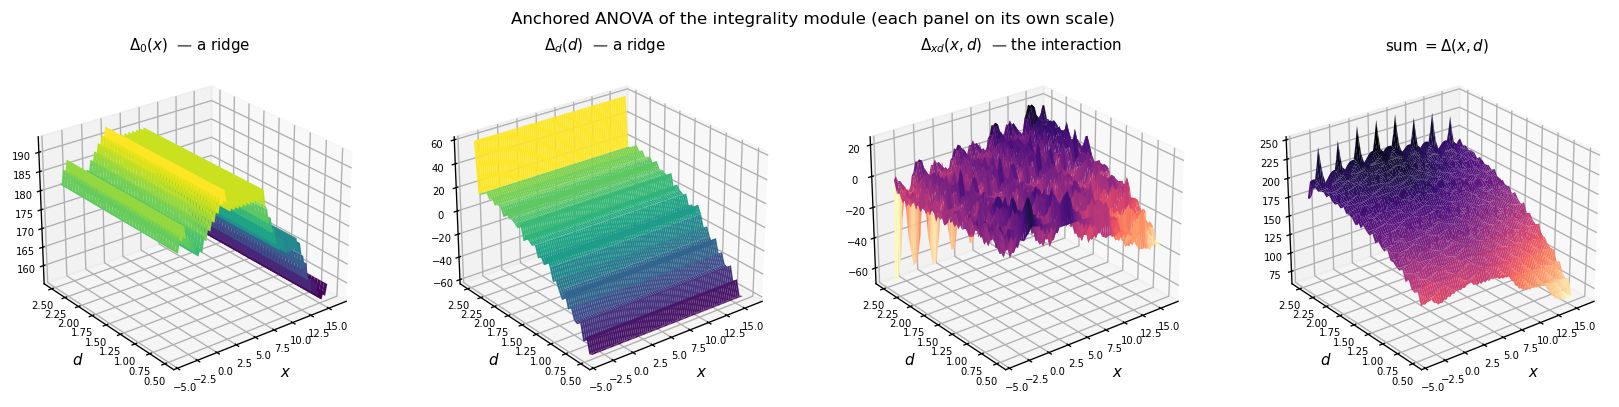

In [28]:
ELEV, AZIM = 26, -128


def surf(ax, Z, title, zlim=None, cmap="viridis"):
    ax.plot_surface(GX, GD, Z, cmap=cmap, linewidth=0, antialiased=True,
                    rstride=1, cstride=1)
    ax.set_xlabel(r"$x$", labelpad=-4); ax.set_ylabel(r"$d$", labelpad=-4)
    ax.set_title(title, fontsize=9, pad=2)
    ax.view_init(elev=ELEV, azim=AZIM)
    ax.tick_params(labelsize=6, pad=-2)
    if zlim:
        ax.set_zlim(*zlim)


zmax = float(VINT.max())
fig = plt.figure(figsize=(11, 3.4))
for j, (Z, t, zl, cm) in enumerate([
        (VREL, r"$V_{\rm rel}(x,d)$  — relaxed baseline", (0, zmax), "viridis"),
        (DELTA, r"$\Delta(x,d)$  — integrality module", None, "magma_r"),
        (VINT, r"sum $=V_{\rm int}(x,d)$", (0, zmax), "viridis")]):
    ax = fig.add_subplot(1, 3, j + 1, projection="3d")
    surf(ax, Z, t, zlim=zl, cmap=cm)
fig.suptitle(r"Baseline plus correction: $V_{\rm int} = V_{\rm rel} + \Delta$", fontsize=10)
fig.tight_layout()
plt.show()

fig = plt.figure(figsize=(14, 3.4))
for j, (Z, t, cm) in enumerate([
        (full_g(D0[:, None]), r"$\Delta_0(x)$  — a ridge", "viridis"),
        (full_g(Dd[None, :]), r"$\Delta_d(d)$  — a ridge", "viridis"),
        (Dxd, r"$\Delta_{xd}(x,d)$  — the interaction", "magma_r"),
        (DELTA, r"sum $=\Delta(x,d)$", "magma_r")]):
    ax = fig.add_subplot(1, 4, j + 1, projection="3d")
    surf(ax, Z, t, cmap=cm)
fig.suptitle("Anchored ANOVA of the integrality module (each panel on its own scale)", fontsize=10)
fig.tight_layout()
plt.show()

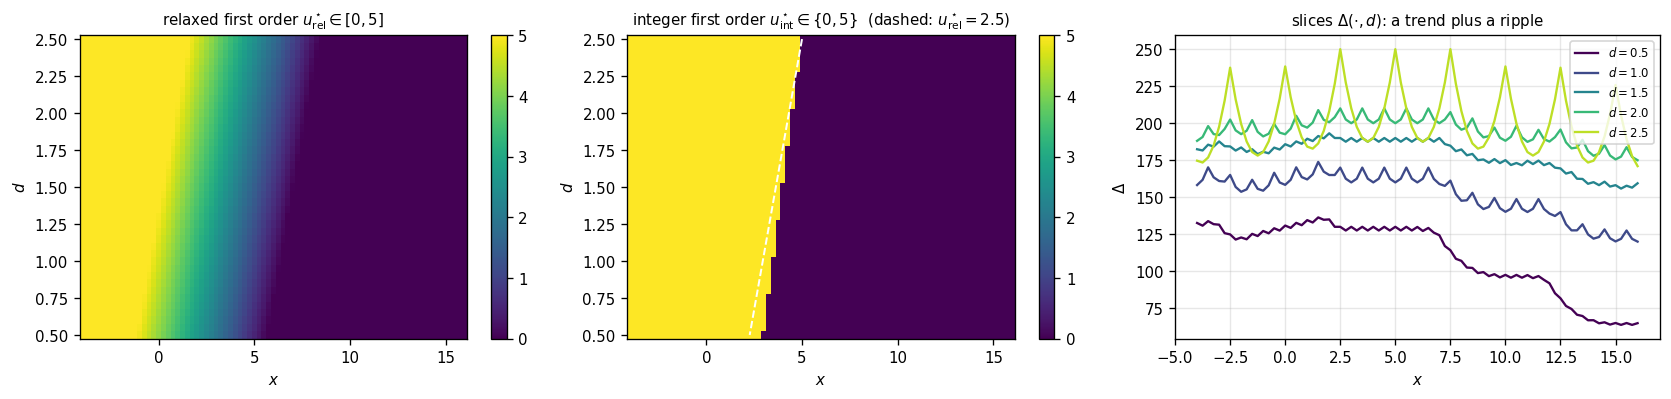

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
im = ax[0].pcolormesh(GX, GD, UREL, cmap="viridis", shading="auto")
ax[0].set_title(r"relaxed first order $u^\star_{\rm rel}\in[0,5]$", fontsize=9)
plt.colorbar(im, ax=ax[0])
im = ax[1].pcolormesh(GX, GD, UINT, cmap="viridis", shading="auto")
ax[1].contour(GX, GD, UREL, levels=[LOT / 2], colors="w", linestyles="--", linewidths=1.2)
ax[1].set_title(r"integer first order $u^\star_{\rm int}\in\{0,5\}$  (dashed: $u^\star_{\rm rel}=2.5$)", fontsize=9)
plt.colorbar(im, ax=ax[1])
for a in ax[:2]:
    a.set_xlabel(r"$x$"); a.set_ylabel(r"$d$")
for c, j in zip(plt.cm.viridis(np.linspace(0.0, 0.9, 5)), np.linspace(0, ND - 1, 5).astype(int)):
    ax[2].plot(xg, DELTA[:, j], color=c, lw=1.4, label=fr"$d={dg[j]:.1f}$")
ax[2].set_xlabel(r"$x$"); ax[2].set_ylabel(r"$\Delta$")
ax[2].set_title(r"slices $\Delta(\cdot,d)$: a trend plus a ripple", fontsize=9)
ax[2].legend(fontsize=7)
fig.tight_layout()
plt.show()

The integer controller switches from buying to waiting along a sharp boundary. The relaxed first order changes gradually, and rounding it at 2.5 (dashed) switches at a different inventory, most visibly at low and high demand.

The slices of $\Delta$ show a trend in $x$ plus a ripple. The ripple arises because the integer controller can only reach inventories on the lattice $x_0+5m-kd$. It is strongest when a lot covers a whole number of steps (e.g. $d=2.5$). The reachable inventories are then fixed by the initial one, and some initial inventories can never be centred on $x_{\rm ref}$. Much of the ripple repeats with the lot size, so it cancels in the decision.

## 4. Learn the baseline and the first-order integrality modules

**Relaxed baseline.** $V_{\rm rel}$ comes from a convex QP, so it is cheap to sample densely. It is learned once with an RBF network from relaxed solves on a coarse grid, and fitted essentially exactly.

**First-order integrality modules.** $\Delta_0$ needs the mixed-integer expert only along the line $d=d_0$, and $\Delta_d$ only along $x=\bar x$. Both are **1-D** regressions, learned from 1-D sweeps of the mixed-integer expert (41 and 21 solves). The target is the expert value minus the learned baseline.

**Smoothing.** $\Delta$ is a trend plus a ripple, and much of the ripple cancels in the lot difference that the decision uses (Section 3). The RBF networks for the integrality modules therefore use a smoothing term, which averages the ripple rather than interpolating it. 

In [30]:
LAM_MOD, LAM_MONO = 3.0, 0.1       # RBF smoothing:

# inputs scaled to [-1, 1]
XC, XH = 0.5 * (XLO + XHI), 0.5 * (XHI - XLO)
DC, DH = 0.5 * (DLO + DHI), 0.5 * (DHI - DLO)
sx = lambda x: (np.atleast_1d(x) - XC) / XH
sd = lambda d: (np.atleast_1d(d) - DC) / DH
sxd = lambda x, d: np.column_stack([sx(x), sd(d)])

# relaxed baseline: convex QPs on a coarse grid (cheap)
bx, bd = np.meshgrid(np.linspace(XLO, XHI, 41), np.linspace(DLO, DHI, 21), indexing="ij")
t0 = time.time()
vr_tr = np.array([V_relaxed(x, d) for x, d in zip(bx.ravel(), bd.ravel())])
rbf_rel = RBFInterpolator(sxd(bx.ravel(), bd.ravel()), vr_tr, kernel="thin_plate_spline", smoothing=1e-8, degree=2)
Vrel_hat = lambda x, d: rbf_rel(sxd(x, d))
e = np.abs(Vrel_hat(GX.ravel(), GD.ravel()).reshape(GX.shape) - VREL) / np.maximum(VREL, 1.0)
print(f"V_rel_hat: {bx.size} relaxed solves in {time.time()-t0:.1f} s;  rel. error on the grid  median {np.median(e):.1e}")

# first-order integrality modules: 1-D sweeps of the mixed-integer expert along the anchor cross
xs1 = np.linspace(XLO, XHI, 41)
ds1 = np.linspace(DLO, DHI, 21)
vi_x = V_integer(xs1, d_0)                                       # 41 mixed-integer solves
vi_d = np.array([V_integer(x_bar, z)[0] for z in ds1])           # 21 mixed-integer solves
dl_x = vi_x - Vrel_hat(xs1, np.full(xs1.size, d_0))              # Delta(x, d_0)
dl_d = vi_d - Vrel_hat(np.full(ds1.size, x_bar), ds1)            # Delta(x_bar, d)
dl_d = dl_d - dl_d[int(np.argmin(abs(ds1 - d_0)))]               # Delta(x_bar, d) - Delta(x_bar, d_0)
print(f"1-D sweeps of the mixed-integer expert: {xs1.size} + {ds1.size} solves")


def fit_first_order(lam):
    r0 = RBFInterpolator(sx(xs1)[:, None], dl_x, kernel="thin_plate_spline", smoothing=lam, degree=2)
    rd = RBFInterpolator(sd(ds1)[:, None], dl_d, kernel="thin_plate_spline", smoothing=lam, degree=2)
    return (lambda x: r0(sx(x)[:, None])), (lambda d: rd(sd(d)[:, None]))


D0_hat, Dd_hat = fit_first_order(LAM_MOD)
e0 = D0_hat(xg) - D0


V_rel_hat: 861 relaxed solves in 0.6 s;  rel. error on the grid  median 4.9e-05
1-D sweeps of the mixed-integer expert: 41 + 21 solves


## 5. Learn the interaction as another module

We query the mixed-integer expert at $n$ points in the joint space (a coarse grid on the two demand edges, so that no fit has to extrapolate, plus random points) and fit an RBF network to the residual

$$V_{\rm int}(x,d) - \hat V_{\rm rel}(x,d) - \hat\Delta_0(x) - \hat\Delta_d(d).$$

The interaction vanishes on the anchor cross, so the 1-D sweep points enter this fit with target zero, at no extra cost.

For comparison, a **monolithic** RBF network $\hat V_{\rm int}(x,d)$ is fitted to the same mixed-integer data: the $n$ joint samples and the 1-D sweeps.

In [31]:
def joint_samples(n, seed):
    # a 5x2 grid on the demand edges (no extrapolation), topped up with uniform random points
    bx_, bd_ = np.meshgrid(np.linspace(XLO, XHI, 5), [DLO, DHI])
    rg_ = np.random.default_rng(seed)
    m = n - bx_.size
    return (np.concatenate([bx_.ravel(), rg_.uniform(XLO, XHI, m)]),
            np.concatenate([bd_.ravel(), rg_.uniform(DLO, DHI, m)]))


# the 1-D sweeps, as points in the joint space
XCROSS = np.concatenate([xs1, np.full(ds1.size, x_bar)])
DCROSS = np.concatenate([np.full(xs1.size, d_0), ds1])
VCROSS = np.concatenate([vi_x, vi_d])


def fit_modular(xs, ds, vs, lam=LAM_MOD):
    D0h, Ddh = fit_first_order(lam)
    res = vs - Vrel_hat(xs, ds) - D0h(xs) - Ddh(ds)
    rbf = RBFInterpolator(np.vstack([sxd(xs, ds), sxd(XCROSS, DCROSS)]),
                          np.concatenate([res, np.zeros(XCROSS.size)]),
                          kernel="thin_plate_spline", smoothing=lam, degree=1)
    Dxh = lambda x, d: rbf(sxd(x, d))
    return lambda x, d: Vrel_hat(x, d) + D0h(x) + Ddh(d) + Dxh(x, d)


def fit_monolithic(xs, ds, vs, lam=LAM_MONO):
    rbf = RBFInterpolator(np.vstack([sxd(xs, ds), sxd(XCROSS, DCROSS)]),
                          np.concatenate([vs, VCROSS]),
                          kernel="thin_plate_spline", smoothing=lam, degree=2)
    return lambda x, d: rbf(sxd(x, d))


N_JOINT = 50
xs2, ds2 = joint_samples(N_JOINT, seed=1)
vs2 = np.array([V_integer(x, d)[0] for x, d in zip(xs2, ds2)])
print(f"joint samples: {N_JOINT} mixed-integer solves;  in total {N_JOINT + xs1.size + ds1.size} mixed-integer solves")

V_mod_hat = fit_modular(xs2, ds2, vs2)
V_mono_hat = fit_monolithic(xs2, ds2, vs2)
V_add_hat = lambda x, d: Vrel_hat(x, d) + D0_hat(x) + Dd_hat(d)          # no interaction module

joint samples: 50 mixed-integer solves;  in total 112 mixed-integer solves


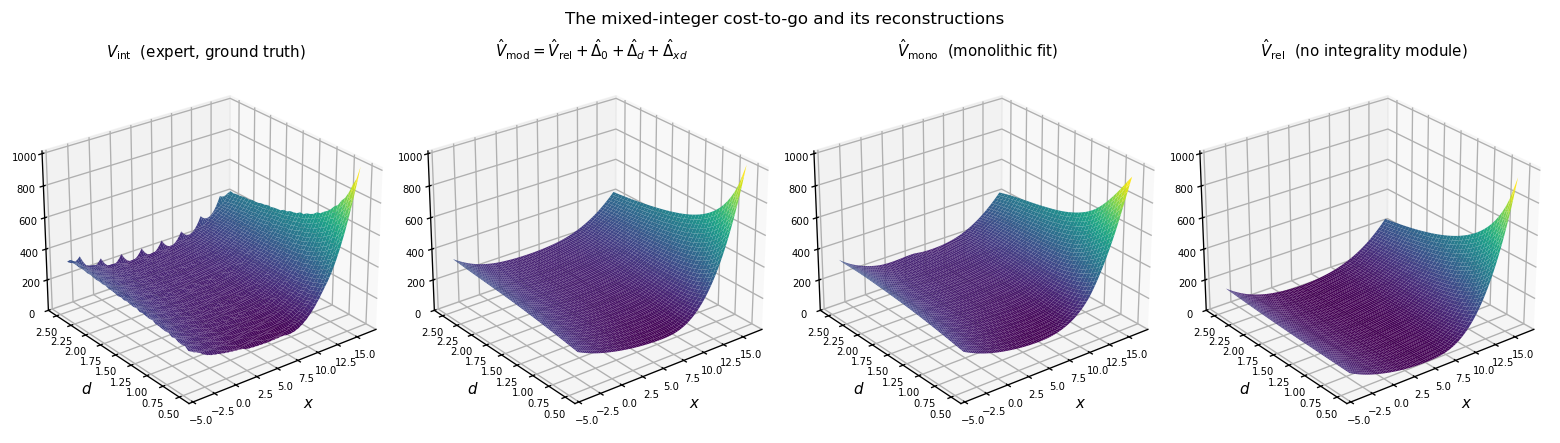

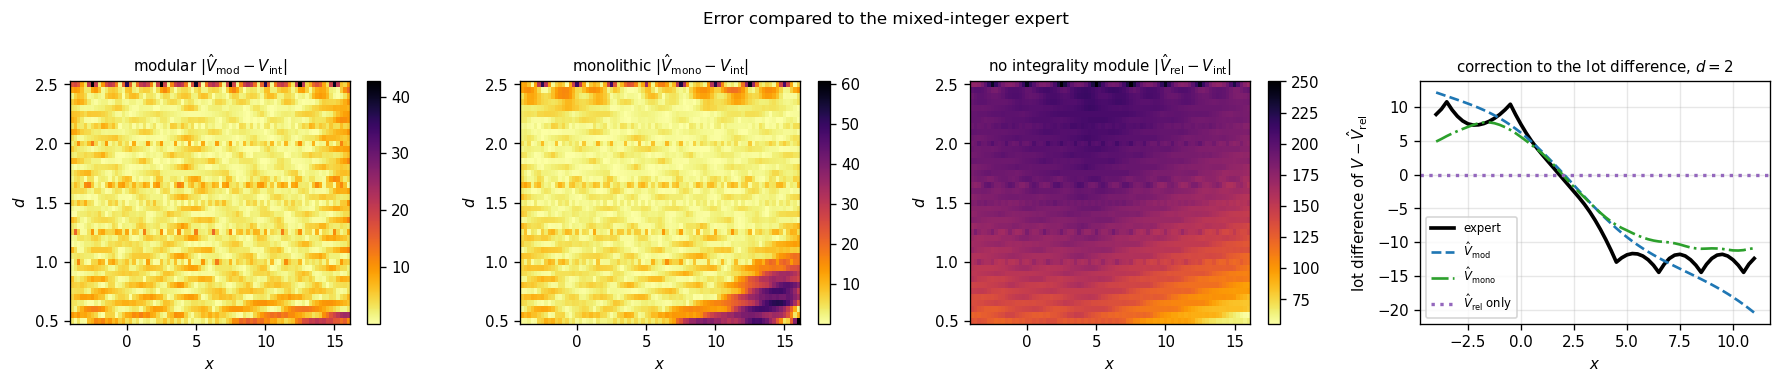

In [32]:
on_grid = lambda f: f(GX.ravel(), GD.ravel()).reshape(GX.shape)
SMOD, SMONO, SADD, SREL = on_grid(V_mod_hat), on_grid(V_mono_hat), on_grid(V_add_hat), on_grid(Vrel_hat)

zl = (0, float(VINT.max()))
fig = plt.figure(figsize=(13, 3.8))
for j, (Z, t) in enumerate([
        (VINT, r"$V_{\rm int}$  (expert, ground truth)"),
        (SMOD, r"$\hat V_{\rm mod}=\hat V_{\rm rel}+\hat\Delta_0+\hat\Delta_d+\hat\Delta_{xd}$"),
        (SMONO, r"$\hat V_{\rm mono}$  (monolithic fit)"),
        (SREL, r"$\hat V_{\rm rel}$  (no integrality module)")]):
    ax = fig.add_subplot(1, 4, j + 1, projection="3d")
    surf(ax, Z, t, zlim=zl)
fig.suptitle("The mixed-integer cost-to-go and its reconstructions", fontsize=10)
fig.tight_layout()
plt.show()

E_MOD, E_MONO, E_REL = np.abs(SMOD - VINT), np.abs(SMONO - VINT), np.abs(SREL - VINT)
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
for a, (E, t) in zip(ax[:3], [(E_MOD, r"modular $|\hat V_{\rm mod}-V_{\rm int}|$"),
                              (E_MONO, r"monolithic $|\hat V_{\rm mono}-V_{\rm int}|$"),
                              (E_REL, r"no integrality module $|\hat V_{\rm rel}-V_{\rm int}|$")]):
    im = a.pcolormesh(GX, GD, E, cmap="inferno_r", shading="auto")
    a.set_xlabel(r"$x$"); a.set_ylabel(r"$d$"); a.set_title(t, fontsize=9)
    plt.colorbar(im, ax=a)
jc = int(np.argmin(abs(dg - 2.0)))
xl = xg[:-SHIFT]
ax[3].plot(xl, lot(VINT - SREL)[:, jc], "k-", lw=2.2, label=r"expert")
ax[3].plot(xl, lot(SMOD - SREL)[:, jc], "--", color="tab:blue", lw=1.6, label=r"$\hat V_{\rm mod}$")
ax[3].plot(xl, lot(SMONO - SREL)[:, jc], "-.", color="tab:green", lw=1.6, label=r"$\hat V_{\rm mono}$")
ax[3].axhline(0.0, ls=":", color="tab:purple", lw=2.0, label=r"$\hat V_{\rm rel}$ only")
ax[3].set_xlabel(r"$x$"); ax[3].set_ylabel(r"lot difference of $V-\hat V_{\rm rel}$")
ax[3].set_title(fr"correction to the lot difference, $d={dg[jc]:g}$", fontsize=9)
ax[3].legend(fontsize=7)
fig.suptitle("Error compared to the mixed-integer expert", fontsize=10)
fig.tight_layout()
plt.show()



## 6. From cost-to-go to policy: 1-step integer MPC vs the expert

Each learned cost-to-go is used as the terminal cost of the 1-step integer MPC from Section 2, and compared with the expert on the same test states: in the first order, and in closed loop.

V_int (exact)                           100.0%        100.0%         +0.28%      +5.42%
V_rel only (exact relaxed QP)            96.0%         80.0%         +5.44%     +22.58%
round relaxed order to a lot             96.0%         80.0%         +4.89%     +20.25%
V_int (exact)                           100.0%        100.0%         +0.28%      +5.42%
V_rel_hat only (no correction)           96.0%         80.0%         +5.24%     +22.01%
additive  V_rel+D0+Dd                    97.0%         85.0%         +2.24%     +11.16%
modular  V_rel+D0+Dd+Dxd                100.0%        100.0%         +0.41%      +5.46%
monolithic  V_int                        98.7%         93.3%         +4.49%     +27.18%


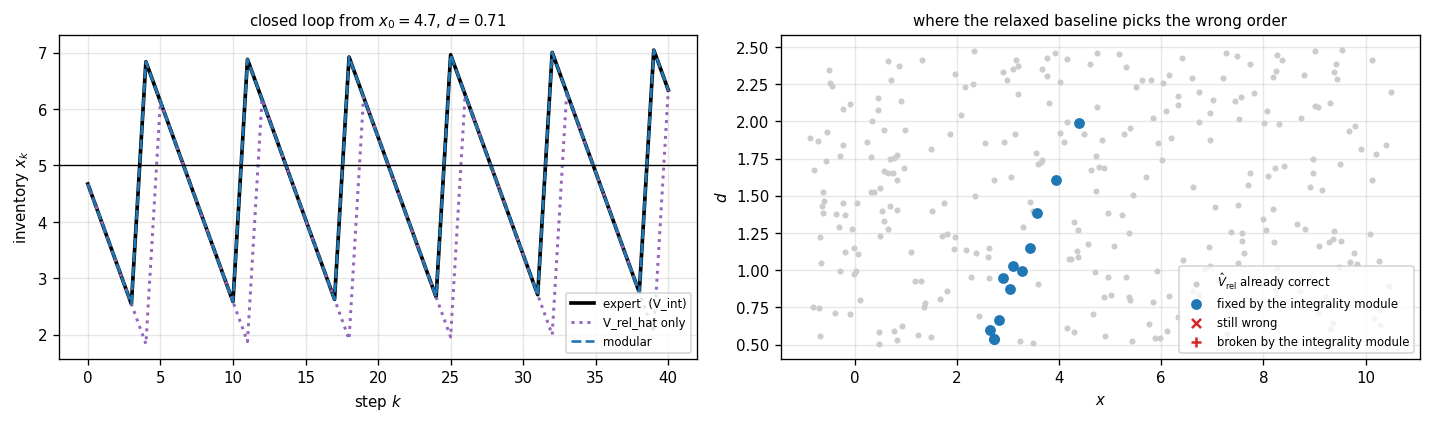

relaxed baseline wrong on 12 of 300 test states: 12 fixed, 0 still wrong; 0 broken by the correction


In [33]:
def stage_cost(x, u, d):
    return q * (x - x_ref) ** 2 + r * (u - d) ** 2


def mpc1(Vfun):
    # 1-step integer MPC, vectorised over states:  argmin_{u in {0, LOT}}  l(x,u,d) + Vfun(x+u-d, d)
    def policy(x, d):
        J0 = stage_cost(x, 0.0, d) + Vfun(x - d, d)
        J1 = stage_cost(x, LOT, d) + Vfun(x + LOT - d, d)
        return np.where(J1 < J0, LOT, 0.0)
    return policy

V_int_exact = lambda xp, dp: np.array([V_integer(a, b)[0] for a, b in zip(xp, dp)])
V_rel_exact = lambda xp, dp: np.array([V_relaxed(a, b) for a, b in zip(xp, dp)])
round_policy = lambda x, d: np.array([LOT if V_relaxed(a, b, want_u=True)[1] > LOT / 2 else 0.0
                                      for a, b in zip(x, d)])

# test states, used for all policy comparisons below
rg = np.random.default_rng(11)
XS_TEST = rg.uniform(-1.0, 10.5, 300); DS_TEST = rg.uniform(DLO, DHI, 300)
U_TEST = np.array([V_integer(x, d, want_u=True)[1][0] for x, d in zip(XS_TEST, DS_TEST)])
MARGIN = np.abs((stage_cost(XS_TEST, LOT, DS_TEST) + V_int_exact(XS_TEST + LOT - DS_TEST, DS_TEST))
                - (stage_cost(XS_TEST, 0.0, DS_TEST) + V_int_exact(XS_TEST - DS_TEST, DS_TEST)))
CLOSE = MARGIN < np.percentile(MARGIN, 20)           # close calls: the 20% of states with the smallest margin

T_CL, N_CL = 40, 100
V_OPT = V_int_exact(XS_TEST[:N_CL], DS_TEST[:N_CL])

def closed_loop(policy):
    # cost of T_CL closed-loop steps from the first N_CL test states, relative to the expert's optimum, in %
    x, d = XS_TEST[:N_CL].copy(), DS_TEST[:N_CL]
    cost = np.zeros(N_CL)
    for k in range(T_CL):
        u = policy(x, d)
        cost += stage_cost(x, u, d); x = x + u - d
    cost += P * (x - x_ref) ** 2
    return 100 * (cost - V_OPT) / V_OPT


def report(name, policy):
    u = policy(XS_TEST, DS_TEST); cl = closed_loop(policy)
    print(f"{name:34s} {100*np.mean(u == U_TEST):10.1f}% {100*np.mean(u[CLOSE] == U_TEST[CLOSE]):12.1f}%"
          f" {cl.mean():+13.2f}% {cl.max():+10.2f}%")
    return cl

CL = {"exact V_int": report("V_int (exact)", mpc1(V_int_exact)),
      "V_rel only": report("V_rel only (exact relaxed QP)", mpc1(V_rel_exact)),
      "rounding": report("round relaxed order to a lot", round_policy)}

report("V_int (exact)", mpc1(V_int_exact))
for name, f in [("V_rel_hat only (no correction)", Vrel_hat), ("additive  V_rel+D0+Dd", V_add_hat),
                ("modular  V_rel+D0+Dd+Dxd", V_mod_hat), ("monolithic  V_int", V_mono_hat)]:
    CL[name] = report(name, mpc1(f))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
# (a) one closed-loop trajectory: the state where the relaxed baseline does worst
i0 = int(np.argmax(CL["V_rel_hat only (no correction)"]))
kk = np.arange(T_CL + 1)
for name, f, c, ls, lw in [("expert  (V_int)", V_int_exact, "k", "-", 2.2),
                           ("V_rel_hat only", Vrel_hat, "tab:purple", ":", 1.8),
                           ("modular", V_mod_hat, "tab:blue", "--", 1.6)]:
    pol = mpc1(f); x, d = XS_TEST[i0], DS_TEST[i0]; xs_ = [x]
    for k in range(T_CL):
        x = x + pol(np.array([x]), np.array([d]))[0] - d; xs_.append(x)
    ax[0].plot(kk, xs_, ls, color=c, lw=lw, label=name)
ax[0].axhline(x_ref, color="k", lw=0.8)
ax[0].set_xlabel("step $k$"); ax[0].set_ylabel(r"inventory $x_k$")
ax[0].set_title(fr"closed loop from $x_0={XS_TEST[i0]:.1f}$, $d={DS_TEST[i0]:.2f}$", fontsize=9)
ax[0].legend(fontsize=7)

# (b) where the relaxed baseline picks the wrong order, and whether the modular cost-to-go fixes it
u_rel = mpc1(Vrel_hat)(XS_TEST, DS_TEST); u_mod = mpc1(V_mod_hat)(XS_TEST, DS_TEST)
wrong = u_rel != U_TEST; fixed = wrong & (u_mod == U_TEST); still = wrong & ~fixed; broke = ~wrong & (u_mod != U_TEST)
ax[1].scatter(XS_TEST[~wrong & ~broke], DS_TEST[~wrong & ~broke], s=7, color="0.8", label=r"$\hat V_{\rm rel}$ already correct")
ax[1].scatter(XS_TEST[fixed], DS_TEST[fixed], s=30, color="tab:blue", label="fixed by the integrality module")
ax[1].scatter(XS_TEST[still], DS_TEST[still], s=30, color="tab:red", marker="x", label="still wrong")
ax[1].scatter(XS_TEST[broke], DS_TEST[broke], s=30, color="tab:red", marker="+", label="broken by the integrality module")
ax[1].set_xlabel(r"$x$"); ax[1].set_ylabel(r"$d$")
ax[1].set_title("where the relaxed baseline picks the wrong order", fontsize=9)
ax[1].legend(fontsize=7)
fig.tight_layout()
plt.show()
print(f"relaxed baseline wrong on {wrong.sum()} of {len(XS_TEST)} test states: {fixed.sum()} fixed, {still.sum()} still wrong; "
      f"{broke.sum()} broken by the correction")

## Summary

* Integrality is treated as one more input of the cost-to-go, anchored at its relaxed value: $V_{\rm int} = V_{\rm rel} + \Delta$. The relaxed baseline comes from a convex QP; only the integrality module needs the mixed-integer expert. The identity is exact, and anchored ANOVA splits $\Delta$ further into $\Delta_0(x)$, $\Delta_d(d)$ and $\Delta_{xd}(x,d)$.
* While the closed-loop performance in this example was already coorect with the relaxed cost-to-go $\hat{V}_{rel}$, the integrality module would be important to enforce descent conditions necessary for closed-loop guarantees. 